# 02 — Feature Engineering
**Banking Churn Prediction**

Aplicamos el `ChurnFeatureEngineer` y el pipeline de preprocesamiento definido en `src/features.py`, validando cada transformación con el dataset real.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from data_processing import load_raw, basic_cleaning, split_features_target
from features import ChurnFeatureEngineer, build_preprocessor, build_feature_pipeline

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

df = load_raw('../data/raw/Customer-Churn-Records.csv')
df = basic_cleaning(df)
X, y = split_features_target(df)
print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')
X.dtypes

Features: 13 | Samples: 10000


CreditScore             int64
Geography                 str
Gender                    str
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Satisfaction Score      int64
Card Type                 str
Point Earned            int64
dtype: object

## 1. Aplicar ChurnFeatureEngineer

In [2]:
engineer = ChurnFeatureEngineer()
X_eng = engineer.fit_transform(X)

new_cols = ['age_segment', 'zero_balance', 'balance_per_product',
            'products_3plus', 'is_german', 'engagement_score', 'risk_profile']

print('=== FEATURES AÑADIDAS ===')
print(X_eng[new_cols].describe().T.round(3).to_string())
print(f'\nColumnas totales después de engineering: {X_eng.shape[1]}')

=== FEATURES AÑADIDAS ===
                       count       mean        std  min  25%       50%         75%         max
zero_balance         10000.0      0.362      0.481  0.0  0.0      0.00       1.000       1.000
balance_per_product  10000.0  62819.699  56783.338  0.0  0.0  61166.24  112654.835  238387.560
products_3plus       10000.0      0.033      0.178  0.0  0.0      0.00       0.000       1.000
is_german            10000.0      0.251      0.434  0.0  0.0      0.00       1.000       1.000
engagement_score     10000.0      0.525      0.834  0.0  0.0      0.00       1.099       2.398
risk_profile         10000.0      0.797      0.686  0.0  0.0      1.00       1.000       3.000

Columnas totales después de engineering: 20


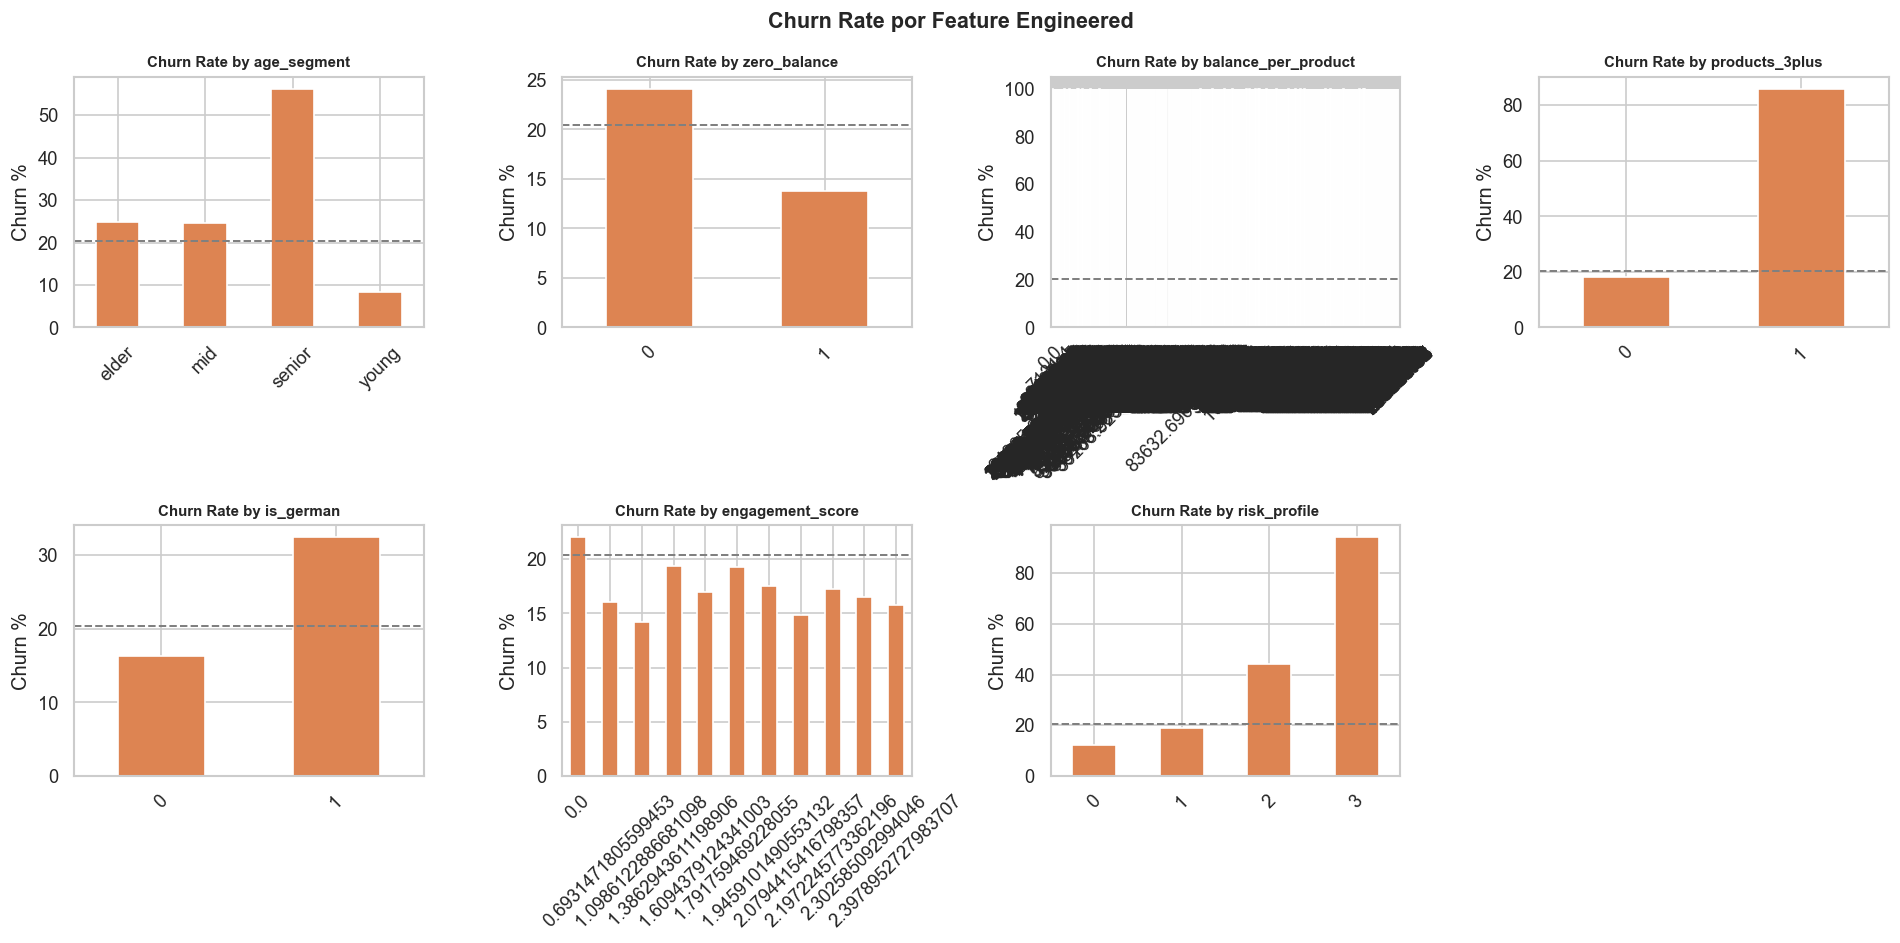

In [3]:
X_eng['Exited'] = y.values

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(new_cols):
    ax = axes[i]
    churn_rate = X_eng.groupby(col)['Exited'].mean() * 100
    churn_rate.plot(kind='bar', ax=ax, color='#DD8452', edgecolor='white')
    ax.axhline(20.4, color='gray', linestyle='--', linewidth=1.2, label='Avg')
    ax.set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=9)
    ax.set_ylabel('Churn %')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

axes[-1].axis('off')
plt.suptitle('Churn Rate por Feature Engineered', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

X_eng = X_eng.drop(columns=['Exited'])

## 2. Encoding + Scaling — ColumnTransformer

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

pipe = build_feature_pipeline()
X_train_enc = pipe.fit_transform(X_train, y_train)
X_test_enc = pipe.transform(X_test)

feature_names = list(pipe.named_steps['preprocessor'].get_feature_names_out())
print(f'Features tras encoding: {len(feature_names)}')
print('Nombres:', feature_names)

enc_df = pd.DataFrame(X_train_enc, columns=feature_names)
print('\nShape train encoded:', enc_df.shape)
enc_df.describe().T.round(3)

Features tras encoding: 23
Nombres: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Point Earned', 'balance_per_product', 'engagement_score', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'zero_balance', 'products_3plus', 'is_german', 'risk_profile', 'Satisfaction Score', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'Card Type', 'age_segment_mid', 'age_segment_senior', 'age_segment_young']

Shape train encoded: (8000, 23)


,count,mean,std,min,25%,50%,75%,max
CreditScore,8000.0,0.000,1.000,-3.109,-0.689,0.014,0.697,2.062
Age,8000.0,0.000,1.000,-1.983,-0.656,-0.183,0.481,5.029
Tenure,8000.0,-0.000,1.000,-1.733,-0.695,-0.003,1.035,1.727
Balance,8000.0,0.000,1.000,-1.227,-1.227,0.329,0.822,2.599
EstimatedSalary,8000.0,-0.000,1.000,-1.733,-0.858,-0.009,0.850,1.750
Point Earned,8000.0,-0.000,1.000,-2.155,-0.872,-0.009,0.858,1.742
balance_per_product,8000.0,0.000,1.000,-1.107,-1.107,-0.031,0.878,3.093
engagement_score,8000.0,-0.000,1.000,-0.633,-0.633,-0.633,0.681,2.236
NumOfProducts,8000.0,1.530,0.582,1.000,1.000,1.000,2.000,4.000
HasCrCard,8000.0,0.708,0.455,0.000,0.000,1.000,1.000,1.000


## 3. Correlación de Features Engineered con Target

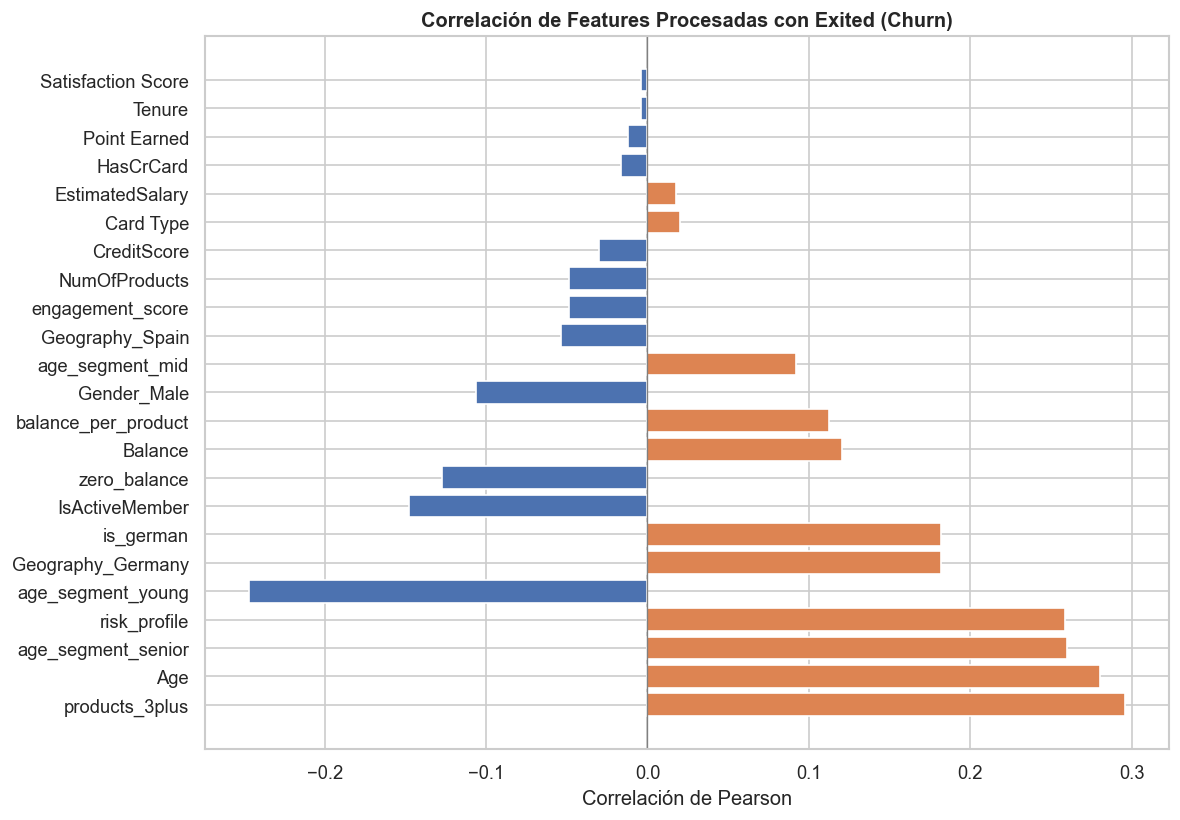


Top 10 features más correlacionadas con churn:
products_3plus        0.295951
Age                   0.280432
age_segment_senior    0.259721
risk_profile          0.259066
age_segment_young    -0.247135
Geography_Germany     0.182070
is_german             0.182070
IsActiveMember       -0.147864
zero_balance         -0.127325
Balance               0.120726


In [5]:
enc_df['Exited'] = y_train.values
corr_target = enc_df.corr()['Exited'].drop('Exited').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Correlación de Features Procesadas con Exited (Churn)', fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print('\nTop 10 features más correlacionadas con churn:')
print(corr_target.head(10).to_string())

enc_df = enc_df.drop(columns=['Exited'])

## 4. SMOTE — Manejo del Desbalance

=== ANTES DE SMOTE ===
Exited
0    6370
1    1630
Ratio: 3.9:1

=== DESPUÉS DE SMOTE ===
  Class 0: 6,370
  Class 1: 6,370
Ratio: 1.0:1 (balanceado)


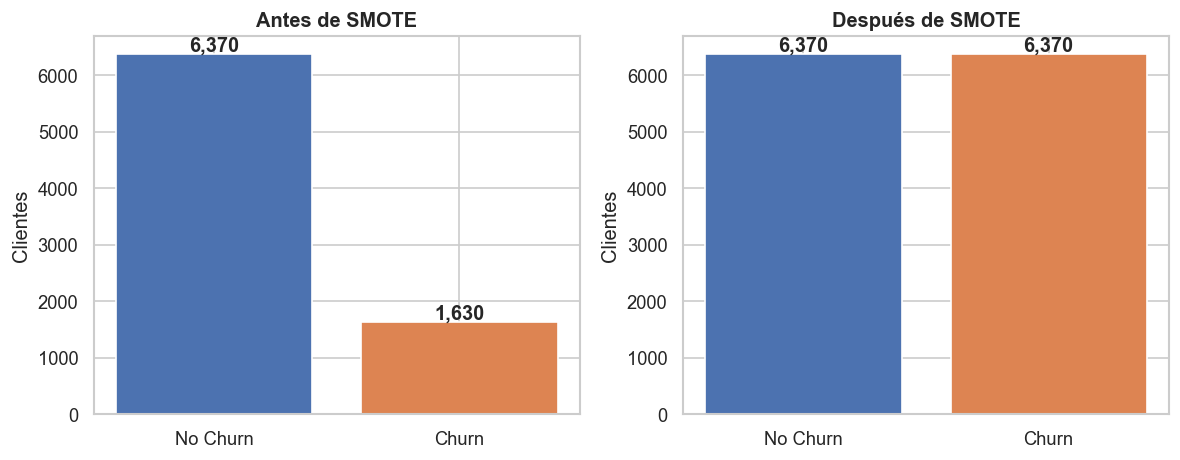

In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X_train_enc, y_train)

print('=== ANTES DE SMOTE ===')
print(y_train.value_counts().to_string())
print(f'Ratio: {y_train.value_counts()[0]/y_train.value_counts()[1]:.1f}:1')

print('\n=== DESPUÉS DE SMOTE ===')
unique, counts = np.unique(y_resampled, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c:,}')
print(f'Ratio: {counts[0]/counts[1]:.1f}:1 (balanceado)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (data, title) in zip(axes, [
    (y_train, 'Antes de SMOTE'),
    (pd.Series(y_resampled), 'Después de SMOTE')
]):
    counts_plot = data.value_counts()
    ax.bar(['No Churn', 'Churn'], counts_plot.sort_index().values,
           color=['#4C72B0', '#DD8452'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Clientes')
    for i, v in enumerate(counts_plot.sort_index().values):
        ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Guardar datos procesados

In [7]:
import pathlib
processed_dir = pathlib.Path('../data/processed')
processed_dir.mkdir(exist_ok=True)

train_df = X_train.copy()
train_df['Exited'] = y_train.values
test_df = X_test.copy()
test_df['Exited'] = y_test.values

train_df.to_csv(processed_dir / 'train.csv', index=False)
test_df.to_csv(processed_dir / 'test.csv', index=False)

print(f'Train guardado: {train_df.shape}')
print(f'Test guardado:  {test_df.shape}')
print(f'Churn rate train: {y_train.mean():.2%} | test: {y_test.mean():.2%}')

Train guardado: (8000, 14)
Test guardado:  (2000, 14)
Churn rate train: 20.38% | test: 20.40%
